Processed parquet saved at data/processed/
Data Summary (Polars):
shape: (9, 20)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ VendorID  ┆ tpep_pick ┆ tpep_drop ┆ … ┆ improveme ┆ total_amo ┆ congestio ┆ airport_ │
│ ---       ┆ ---       ┆ up_dateti ┆ off_datet ┆   ┆ nt_surcha ┆ unt       ┆ n_surchar ┆ fee      │
│ str       ┆ f64       ┆ me        ┆ ime       ┆   ┆ rge       ┆ ---       ┆ ge        ┆ ---      │
│           ┆           ┆ ---       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ f64      │
│           ┆           ┆ str       ┆ str       ┆   ┆ f64       ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 2.91784e6 ┆ 2917840   ┆ 2917840   ┆ … ┆ 2.91784e6 ┆ 2.91784e6 ┆ 2.91784e6 ┆ 2.91784e │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 6        │
│ null_cou

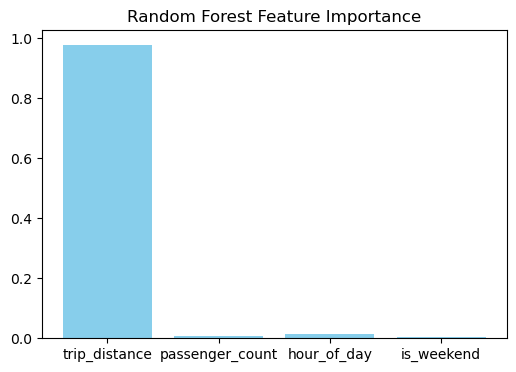

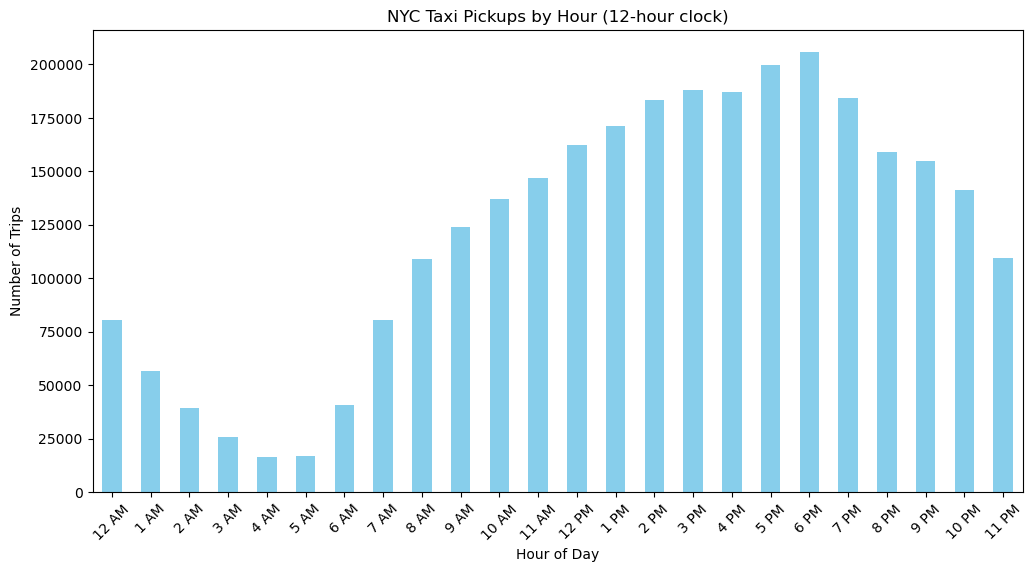

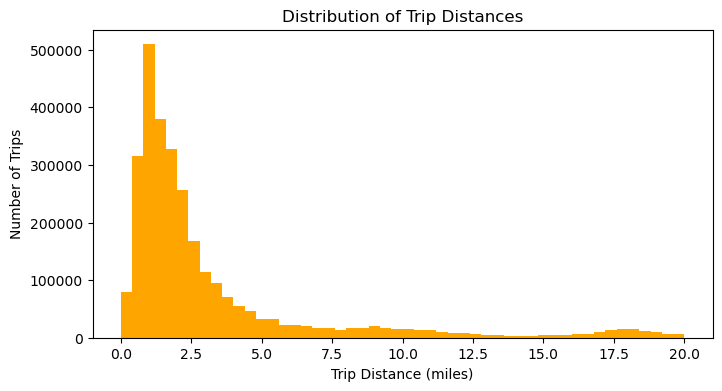

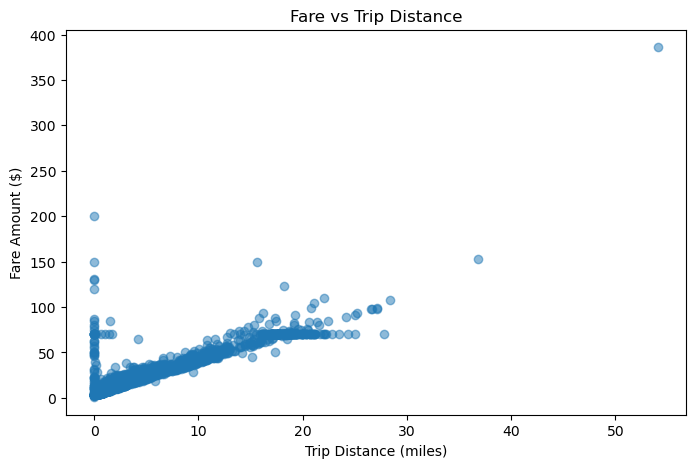

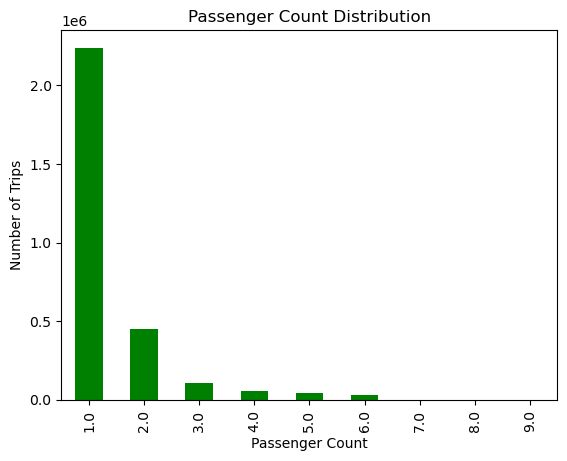

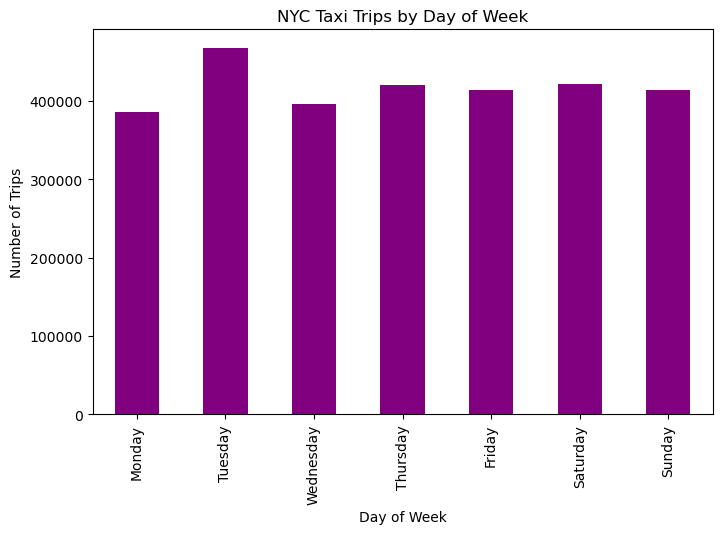

CSV saved successfully at /Users/braydenwhitehead/nyc_taxi_project/data/processed/nyc_taxi_processed.csv
['nyc_taxi_processed.csv']


In [41]:

import os
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


spark = SparkSession.builder.appName("NYC_Taxi").getOrCreate()

raw_file = "/Users/braydenwhitehead/nyc_taxi_project/data/raw/yellow_tripdata_2023-01.parquet"
if not os.path.exists(raw_file):
    raise FileNotFoundError(f"Raw file not found: {raw_file}")

df_spark = spark.read.parquet(raw_file)
df_spark = df_spark.filter(df_spark.fare_amount > 0).filter(df_spark.passenger_count > 0)

processed_path = "data/processed/"
os.makedirs(processed_path, exist_ok=True)
df_spark.write.mode("overwrite").parquet(processed_path)
print(f"Processed parquet saved at {processed_path}")




df = pl.read_parquet(processed_path + "*.parquet")
print("Data Summary (Polars):")
print(df.describe())

df_pandas = df.to_pandas()
df_pandas["tpep_pickup_datetime"] = pd.to_datetime(df_pandas["tpep_pickup_datetime"])

# -------------------------
# Feature Engineering
# -------------------------
df_pandas["hour_of_day"] = df_pandas["tpep_pickup_datetime"].dt.hour
df_pandas["day_of_week"] = df_pandas["tpep_pickup_datetime"].dt.day_name()
df_pandas["is_weekend"] = df_pandas["day_of_week"].isin(["Saturday","Sunday"]).astype(int)

def hour_to_12hr(hour):
    if hour == 0:
        return "12 AM"
    elif hour < 12:
        return f"{hour} AM"
    elif hour == 12:
        return "12 PM"
    else:
        return f"{hour-12} PM"

df_pandas["hour_12hr"] = df_pandas["hour_of_day"].apply(hour_to_12hr)




features = ["trip_distance", "passenger_count", "hour_of_day", "is_weekend"]
X = df_pandas[features]
y = df_pandas["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
print("Random Forest R^2 Score:", model.score(X_test, y_test))

# Feature importance
plt.figure(figsize=(6,4))
plt.bar(features, model.feature_importances_, color="skyblue")
plt.title("Random Forest Feature Importance")
plt.show()




hour_order = [
    "12 AM","1 AM","2 AM","3 AM","4 AM","5 AM","6 AM","7 AM","8 AM","9 AM","10 AM","11 AM",
    "12 PM","1 PM","2 PM","3 PM","4 PM","5 PM","6 PM","7 PM","8 PM","9 PM","10 PM","11 PM"
]
hour_counts = df_pandas["hour_12hr"].value_counts().reindex(hour_order, fill_value=0)

plt.figure(figsize=(12,6))
hour_counts.plot(kind="bar", color="skyblue")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("NYC Taxi Pickups by Hour (12-hour clock)")
plt.xticks(rotation=45)
plt.show()

   #Trip Distance Distribution
plt.figure(figsize=(8,4))
df_pandas["trip_distance"].plot(kind="hist", bins=50, range=(0,20), color="orange")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distances")
plt.show()

  #Fare vs Trip Distance Scatter
plt.figure(figsize=(8,5))
plt.scatter(
    df_pandas["trip_distance"].sample(5000, random_state=42),
    df_pandas["fare_amount"].sample(5000, random_state=42),
    alpha=0.5
)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Trip Distance")
plt.show()

   #Passenger Count Distribution
df_pandas["passenger_count"].value_counts().sort_index().plot(kind="bar", color="green")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.title("Passenger Count Distribution")
plt.show()

   #Trips by Day of Week
df_pandas["day_of_week"].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", figsize=(8,5), color="purple")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("NYC Taxi Trips by Day of Week")
plt.show()


# Save Processed CSV

project_folder = "/Users/braydenwhitehead/nyc_taxi_project"
os.makedirs(os.path.join(project_folder, "data/processed"), exist_ok=True)
csv_path = os.path.join(project_folder, "data/processed/nyc_taxi_processed.csv")

df_pandas.to_csv(csv_path, index=False)
print(f"CSV saved successfully at {csv_path}")
print(os.listdir(os.path.join(project_folder, "data/processed")))
